In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
import tensorflow as tf
from sklearn.model_selection import train_test_split

print("TensorFlow Version:", tf.__version__)

# Show datasets
print(os.listdir("/kaggle/input"))

2026-06-18 06:23:37.356455: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781763817.559191      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781763817.616228      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781763818.100503      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781763818.100541      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781763818.100544      23 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0
['datasets']


In [2]:
import os

DATASET_PATH = "/kaggle/input/datasets/amalj04/odir7k"

train_path = os.path.join(DATASET_PATH, "train")
val_path = os.path.join(DATASET_PATH, "val")
test_path = os.path.join(DATASET_PATH, "test")

print("Train Classes:")
print(os.listdir(train_path))

print("\nValidation Classes:")
print(os.listdir(val_path))

print("\nTest Classes:")
print(os.listdir(test_path))

Train Classes:
['diabetes', 'hypertension', 'ageDegeneration', 'glaucoma', 'normal', 'cataract', 'myopia']

Validation Classes:
['diabetes', 'hypertension', 'ageDegeneration', 'glaucoma', 'normal', 'cataract', 'myopia']

Test Classes:
['diabetes', 'hypertension', 'ageDegeneration', 'glaucoma', 'normal', 'cataract', 'myopia']


In [3]:
import os

classes = sorted(os.listdir(train_path))

print("Training Images\n")

for cls in classes:

    folder = os.path.join(train_path, cls)

    print(f"{cls} : {len(os.listdir(folder))}")

Training Images

ageDegeneration : 1014
cataract : 1050
diabetes : 1125
glaucoma : 1260
hypertension : 1050
myopia : 979
normal : 2011


In [4]:
print("Validation Images\n")

for cls in classes:

    folder = os.path.join(val_path, cls)

    print(f"{cls} : {len(os.listdir(folder))}")

Validation Images

ageDegeneration : 217
cataract : 225
diabetes : 241
glaucoma : 270
hypertension : 225
myopia : 210
normal : 430


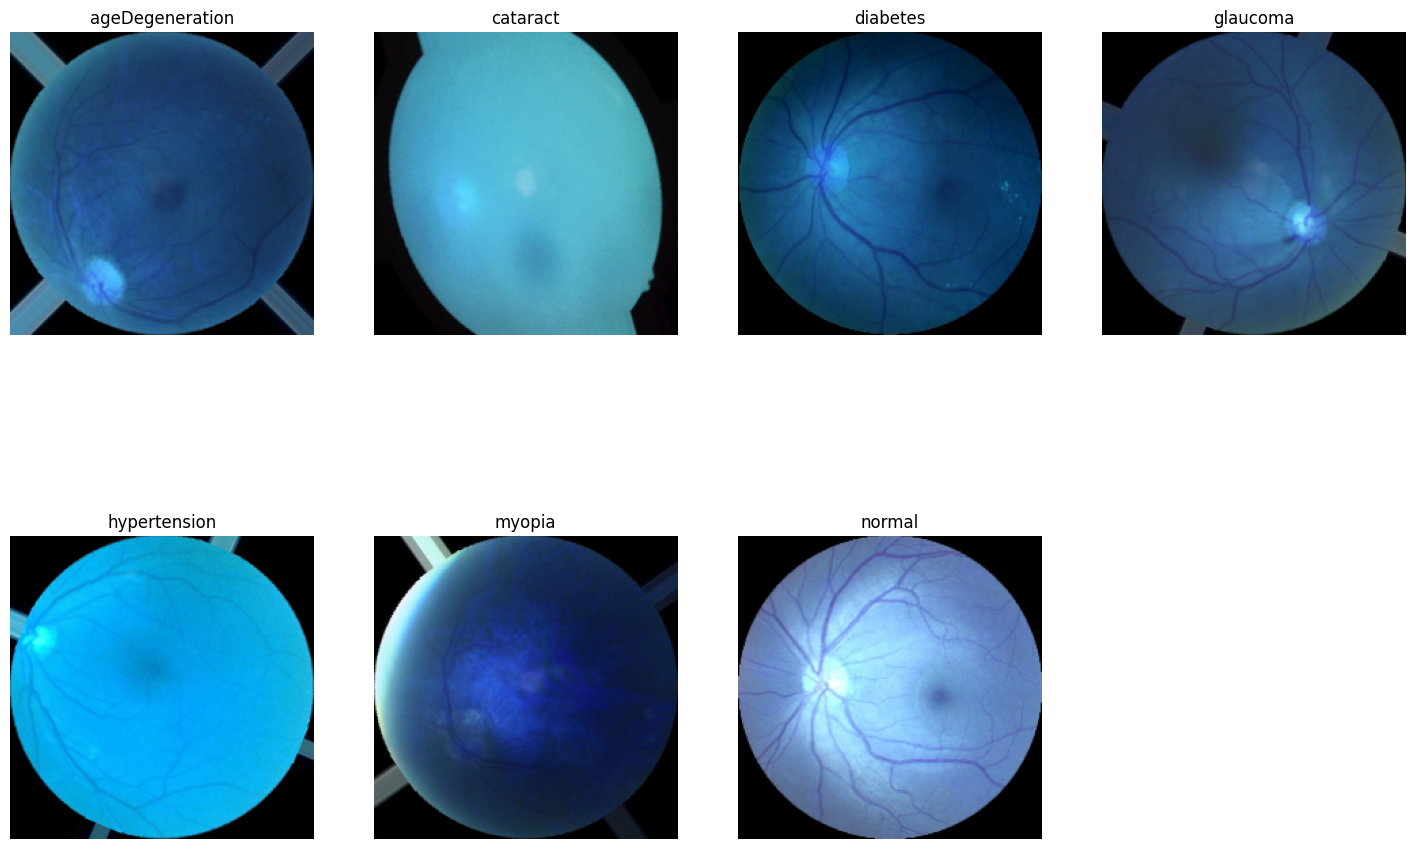

ageDegeneration (224, 224, 3)
cataract (224, 224, 3)
diabetes (224, 224, 3)
glaucoma (224, 224, 3)
hypertension (224, 224, 3)
myopia (224, 224, 3)
normal (224, 224, 3)


In [5]:
import cv2
import matplotlib.pyplot as plt

classes = sorted(os.listdir(train_path))

plt.figure(figsize=(18,12))

for i, cls in enumerate(classes):

    folder = os.path.join(train_path, cls)

    image_name = os.listdir(folder)[0]

    image_path = os.path.join(folder, image_name)

    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2,4,i+1)

    plt.imshow(image)

    plt.title(cls)

    plt.axis("off")

plt.show()

for cls in classes:

    folder = os.path.join(train_path, cls)

    image_name = os.listdir(folder)[0]

    image = cv2.imread(os.path.join(folder,image_name))

    print(cls, image.shape)

In [6]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
DATASET_PATH = "/kaggle/input/datasets/amalj04/odir7k"

train_path = os.path.join(DATASET_PATH, "train")
val_path = os.path.join(DATASET_PATH, "val")
test_path = os.path.join(DATASET_PATH, "test")

classes = sorted(os.listdir(train_path))

print(classes)
def crop_black(img):

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    mask = gray > 10

    if mask.any():

        coords = np.argwhere(mask)

        y0, x0 = coords.min(axis=0)

        y1, x1 = coords.max(axis=0) + 1

        img = img[y0:y1, x0:x1]

    return img

['ageDegeneration', 'cataract', 'diabetes', 'glaucoma', 'hypertension', 'myopia', 'normal']


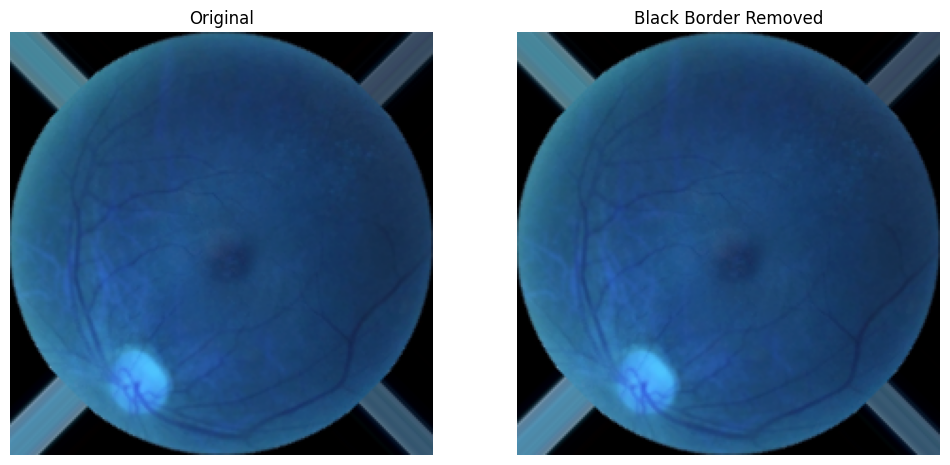

(224, 224, 3)
0.0
1.0


In [7]:
sample_class = classes[0]

sample_folder = os.path.join(train_path, sample_class)

sample_image = os.listdir(sample_folder)[0]

img_path = os.path.join(sample_folder, sample_image)

img = cv2.imread(img_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

crop = crop_black(img)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(crop)
plt.title("Black Border Removed")
plt.axis("off")

plt.show()
crop = cv2.resize(crop, (224,224))

print(crop.shape)
crop = crop.astype(np.float32) / 255.0

print(crop.min())
print(crop.max())

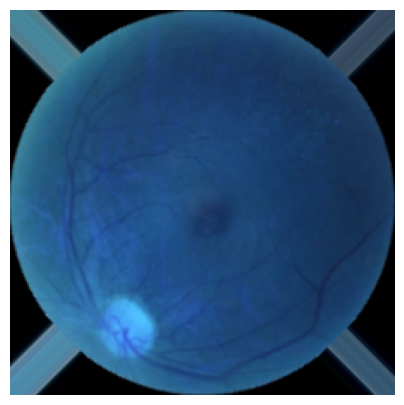

In [8]:
plt.figure(figsize=(5,5))

plt.imshow(crop)

plt.axis("off")

plt.show()

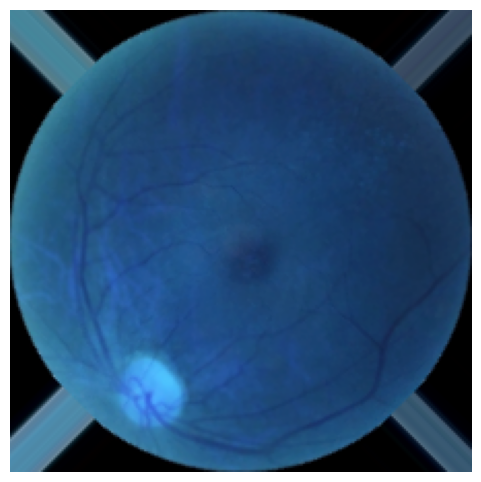

(224, 224, 3)
0 255


In [9]:
def preprocess_image(path):

    img = cv2.imread(path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = crop_black(img)

    img = cv2.resize(img, (224,224))

    img = img.astype(np.float32) / 255.0

    return img
    img = preprocess_image(img_path)

plt.figure(figsize=(6,6))

plt.imshow(img)

plt.axis("off")

plt.show()

print(img.shape)

print(img.min(), img.max())

Found 8489 images belonging to 7 classes.
Found 1818 images belonging to 7 classes.
Found 1824 images belonging to 7 classes.
{'ageDegeneration': 0, 'cataract': 1, 'diabetes': 2, 'glaucoma': 3, 'hypertension': 4, 'myopia': 5, 'normal': 6}


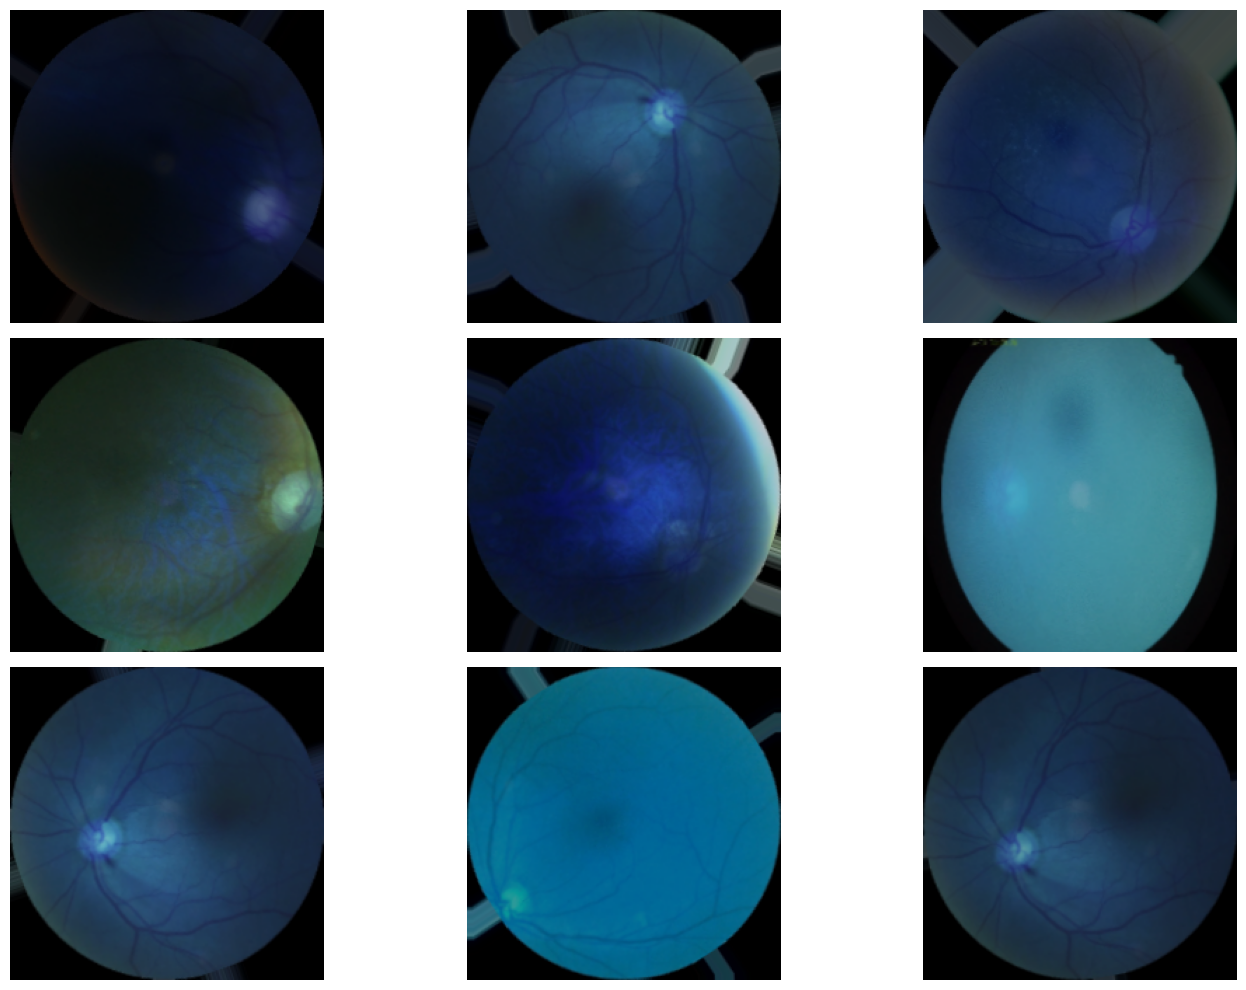

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_generator = ImageDataGenerator(

    rescale=1./255,

    rotation_range=45,

    horizontal_flip=True,

    vertical_flip=True,

    brightness_range=[0.5,0.9],

    fill_mode='nearest'

)

val_generator = ImageDataGenerator(
    rescale=1./255
)

test_generator = ImageDataGenerator(
    rescale=1./255
)
IMG_SIZE = (224,224)

BATCH_SIZE = 32

train_data = train_generator.flow_from_directory(

    train_path,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    shuffle=True

)

val_data = val_generator.flow_from_directory(

    val_path,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    shuffle=False

)

test_data = test_generator.flow_from_directory(

    test_path,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    shuffle=False

)
print(train_data.class_indices)
images, labels = next(train_data)

plt.figure(figsize=(15,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [11]:
from tensorflow.keras.applications import Xception

base_model = Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

I0000 00:00:1781763840.363492      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781763840.369620      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
import tensorflow as tf

print(tf.__version__)
from tensorflow.keras.applications import Xception
base_model = Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

2.19.0


In [13]:
import tensorflow as tf
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
base_model = Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

print("Xception Loaded Successfully!")
base_model.summary()
for layer in base_model.layers:
    layer.trainable = False

print("Backbone Frozen!")

Xception Loaded Successfully!


Model: "xception"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 111, 111,  │        864 │ input_layer_2[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 111, 111,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 111, 111,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 109, 109,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 109, 109,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 109, 109,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 109, 109,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 109, 109,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 109, 109,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 109, 109,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 109, 109,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 55, 55,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 55, 55,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 55, 55,    │        512 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_24 (Add)        │ (None, 55, 55,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 55, 55,    │          0 │ add_24[0][0]    

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 20,806,952 (79.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

Backbone Frozen!


In [14]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    512,
    activation="relu",
    kernel_regularizer=l2(0.01)
)(x)

x = Dropout(0.5)(x)

output = Dense(
    7,
    activation="softmax"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=2e-4
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 111, 111,  │        864 │ input_layer_2[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 111, 111,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 111, 111,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 109, 109,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 109, 109,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 109, 109,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 109, 109,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 109, 109,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 109, 109,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 109, 109,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 109, 109,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 55, 55,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 55, 55,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 55, 55,    │        512 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_24 (Add)        │ (None, 55, 55,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 55, 55,    │          0 │ add_24[0][0]    

 Total params: 21,914,159 (83.60 MB)

 Trainable params: 1,052,679 (4.02 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [15]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30
)

Epoch 1/30


I0000 00:00:1781763851.458317      93 service.cc:152] XLA service 0x7a8d70003f60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781763851.458363      93 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781763851.458371      93 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781763852.646770      93 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-18 06:24:21.497489: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-18 06:24:21.678088: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-18 06:24:23.423643: E external/local_xl

 67/266 ━━━━━━━━━━━━━━━━━━━━ 1:48 547ms/step - accuracy: 0.5269 - loss: 8.7577

2026-06-18 06:25:12.679423: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-18 06:25:12.821089: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-18 06:25:13.788102: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-18 06:25:13.921161: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-18 06:25:14.757103: E external/local_xla/xla/stream_

266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.6430 - loss: 6.7728

2026-06-18 06:27:29.983716: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-18 06:27:30.158294: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-18 06:27:32.066219: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-18 06:27:32.203069: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-18 06:27:33.308127: E external/local_xla/xla/stream_

266/266 ━━━━━━━━━━━━━━━━━━━━ 211s 706ms/step - accuracy: 0.7179 - loss: 4.9188 - val_accuracy: 0.7921 - val_loss: 2.6250
Epoch 2/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 125s 470ms/step - accuracy: 0.7710 - loss: 1.9800 - val_accuracy: 0.7926 - val_loss: 1.5683
Epoch 3/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 131s 491ms/step - accuracy: 0.7765 - loss: 1.3126 - val_accuracy: 0.8003 - val_loss: 1.0927
Epoch 4/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 131s 494ms/step - accuracy: 0.7800 - loss: 1.0323 - val_accuracy: 0.8047 - val_loss: 0.9200
Epoch 5/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 127s 476ms/step - accuracy: 0.7837 - loss: 0.8878 - val_accuracy: 0.8020 - val_loss: 0.8424
Epoch 6/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 126s 474ms/step - accuracy: 0.7816 - loss: 0.8099 - val_accuracy: 0.8020 - val_loss: 0.7884
Epoch 7/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 127s 476ms/step - accuracy: 0.7862 - loss: 0.7651 - val_accuracy: 0.7998 - val_loss: 0.7302
Epoch 8/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 129s 484ms/step - accuracy: 0.7893 - loss: 0.73